# Clase 6: Bonus AutoML y NLP Clásico
---

<img src="../img/sergio_portrait_square.png" alt="Sergio Benito" align="right" width="100">

- **Autor:** Sergio Benito Martín
- **Contacto:** pontia@sergiobenito.com
- **Última actualización:** 10/07/2025

### Objetivo
Dar algo más de contexto sobre algunas técnicas y tecnologías que se pueden utilizar para hacer más facilitar el flujo de trabajo de ML así como conocer algunas técnicas básicas de NLP clásico.

### Temas a tratar

1. AutoML con PyCaret
2. NLP Clásico
3. Ejercicios para practicar

### Información útil
+ Documentación oficial:
  + PyCaret: [Documentación oficial](https://pycaret.gitbook.io/docs)
    + [Modelos supervisados - Clasificación](https://pycaret.gitbook.io/docs/get-started/quickstart#classification)
    + [Modelos supervisados - Regresión](https://pycaret.gitbook.io/docs/get-started/quickstart#regression)
    + [Modelos no supervisados - Clustering](https://pycaret.gitbook.io/docs/get-started/quickstart#clustering)
    + [Modelos no supervisados - Detección de anomalías](https://pycaret.gitbook.io/docs/get-started/quickstart#anomaly-detection)
    + [Modelos de series temporales](https://pycaret.gitbook.io/docs/get-started/quickstart#time-series)
  + NLP:
    + [Gensim - Word2Vec](https://radimrehurek.com/gensim/auto_examples/tutorials/run_word2vec.html)
    + [NLTK](https://www.nltk.org/)
    + [Spacy](https://spacy.io/)
+ Medium:
  + [A Dummy’s Guide to Word2Vec](https://medium.com/@manansuri/a-dummys-guide-to-word2vec-456444f3c673)
---


### Para profundizar más 🤓

| Librería         | ¿Para qué se usa?                                         | Ventajas principales                       | Ejemplo de uso típico                        |
|------------------|-----------------------------------------------------------|--------------------------------------------|----------------------------------------------|
| **NLTK**         | Procesamiento lingüístico básico: tokenización, stemming, lemmatización, análisis gramatical, corpus, etc. | Muy completa y didáctica, muchos recursos y corpus incluidos, ideal para aprender | Tokenizar texto, obtener raíces de palabras  |
| **spaCy**        | Procesamiento rápido y eficiente a nivel industrial: tokenización, lemmatización, PoS tagging, dependencias, entidades, etc. | Muy rápido, fácil de usar, modelos preentrenados para varios idiomas | Extraer entidades, lematizar textos          |
| **re (regex)**   | Búsqueda y manipulación de texto mediante expresiones regulares | Integrada en Python, muy útil para limpieza y extracción de patrones | Buscar emails, limpiar HTML, extraer fechas  |
| **TextBlob**     | Procesamiento sencillo: análisis de sentimientos, traducción, spelling, tokenización | Muy fácil de usar, buena para prototipos y análisis rápido | Analizar sentimiento de un texto             |
| **Gensim**       | Modelos de tópicos, embeddings y Word2Vec/LDA             | Rápida para modelos de palabras, fácil para trabajar con grandes corpus | Entrenar Word2Vec, obtener similitud         |
| **pattern**      | Procesamiento textual, análisis de sentimiento, extracción de información, web mining | Multitarea, incluye scraping web y análisis gramatical | Scraping y análisis de texto web             |

## 0. Configuración del Notebook
Importaremos todas las librerías y funciones que vemos relevantes para el notebook que vamos a crear. Lo ideal sería tener todas las importaciones juntas, de tal manera que se puedan controlar de manera sencilla.

### Importación de librerías

In [68]:
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import plotly.express as px
import re
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [2]:
# Importamos esta librería para solventar el problema que podáis tener para visualizar gráficos con Plotly
from IPython.display import HTML

### Definición de constantes

In [3]:
# Paths
PATH_DIRECTORIO_DATOS = "../data"

PATH_DATASET_ADVERTISING = f"{PATH_DIRECTORIO_DATOS}/advertising.csv"
PATH_DATASET_CALORIES = f"{PATH_DIRECTORIO_DATOS}/calories.csv"
PATH_DATASET_CALORIES_LITE = f"{PATH_DIRECTORIO_DATOS}/calories_time_reduc.csv"
PATH_DATASET_CALORIES_TIME = f"{PATH_DIRECTORIO_DATOS}/calories_time.csv"
PATH_DATASET_HEART = f"{PATH_DIRECTORIO_DATOS}/heart_disease.csv"
PATH_DATASET_BOSTON = f"{PATH_DIRECTORIO_DATOS}/housing_boston.csv"
PATH_DATASET_TWEETS = f"{PATH_DIRECTORIO_DATOS}/nlp_tweets.csv"

# Datasets de Internet
URL_DATASET_PENGUINS = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"

In [4]:
IF_PLOTLY_FAILS = False

### Definición de funciones

### Carga de datos

#### Heart Disease

In [5]:
# Cargamos el dataset de Heart Disease
df_heart = pd.read_csv(PATH_DATASET_HEART)

In [6]:
# Mostramos las primeras filas del dataset
df_heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [7]:
# Mostramos la información del dataset
df_heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [8]:
# Mostramos las estadísticas del dataset
df_heart.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


#### Tweets

In [9]:
# Cargar el dataset de tweets
df_tweets = pd.read_csv(PATH_DATASET_TWEETS)

# Mostramos las primeras filas del dataset de tweets
df_tweets.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [10]:
# Mostramos la información del dataset de tweets
df_tweets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

In [11]:
# Mostramos las estadísticas de las variables numéricas del dataset de tweets
df_tweets.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
tweet_id,14640.0,5.692184e+17,7.791112e+14,5.675883e+17,5.685592e+17,5.694779e+17,5.698905e+17,5.703106e+17
airline_sentiment_confidence,14640.0,9.001689e-01,1.628300e-01,3.350000e-01,6.923000e-01,1.000000e+00,1.000000e+00,1.000000e+00
negativereason_confidence,10522.0,6.382983e-01,3.304398e-01,0.000000e+00,3.606000e-01,6.706000e-01,1.000000e+00,1.000000e+00
retweet_count,14640.0,8.265027e-02,7.457782e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.400000e+01


In [12]:
# Mostramos las estadísticas de las variables categóricas del dataset de tweets
df_tweets.describe(include=["object"]).transpose()

,count,unique,top,freq
airline_sentiment,14640,3,negative,9178
negativereason,9178,10,Customer Service Issue,2910
airline,14640,6,United,3822
airline_sentiment_gold,40,3,negative,32
name,14640,7701,JetBlueNews,63
negativereason_gold,32,13,Customer Service Issue,12
text,14640,14427,@united thanks,6
tweet_coord,1019,832,"[0.0, 0.0]",164
tweet_created,14640,14247,2015-02-24 09:54:34 -0800,5
tweet_location,9907,3081,"Boston, MA",157


## 1. AutoML con PyCaret
Básicamente el AutoML es la automatización del ciclo de vida de un modelo de ML (preprocesado, selección de modelo, validación, ajuste).
+ Ventajas: rápido, accesible para principiantes, encuentra “buenos” modelos sin ser experto.
+ Limitaciones: caja negra, menos personalización, posible sobreajuste si no se interpreta bien.



PyCaret es una biblioteca de código abierto y de bajo código en Python diseñada para simplificar y acelerar el proceso de desarrollo de modelos de aprendizaje automático (machine learning). Actúa como un envoltorio (wrapper) de alto nivel para librerías de machine learning populares como Scikit-learn, XGBoost, LightGBM y CatBoost, permitiendo a los usuarios realizar complejos flujos de trabajo de ciencia de datos con muy pocas líneas de código.

<center><img src="https://pycaret.gitbook.io/docs/~gitbook/image?url=https%3A%2F%2F3811348345-files.gitbook.io%2F%7E%2Ffiles%2Fv0%2Fb%2Fgitbook-x-prod.appspot.com%2Fo%2Fspaces%252FjAq5m5T7Qtz03TnB0Wve%252Fuploads%252F39cmqXko47KE4ca9vUqh%252Fimage.png%3Falt%3Dmedia%26token%3D597f36dd-235a-486c-88f1-a5c7f897c418&width=768&dpr=4&quality=100&sign=84937217&sv=2" alt="PyCaret funcionalidades" width=700></center>
<center><a src="https://pycaret.gitbook.io/docs">Fuente: Documentación oficial PyCaret</a></center>

Tiene diferentes módulos:
```python

# Modelos supervisados
from pycaret import classification as cl
from pycaret import regression as r

# Modelos no supervisados
from pycaret import clustering as ct
from pycaret import anomaly as ad

# Series temporales
from pycaret import time_series as ts
```

In [13]:
from pycaret import classification as cl

In [24]:
# Elige la variable objetivo (cambia si tu dataset usa otro nombre)
target_heart = 'target'

# Separamos el dataset en entrenamiento y test
X_train_heart, X_test_heart, y_train_heart, y_test_heart = train_test_split(
    df_heart.drop(columns=[target_heart]),
    df_heart['target'],
    test_size=0.2,
    random_state=42,
    stratify=df_heart['target']
)

# Concatenamos las variables independientes y la variable objetivo para el entrenamiento y test
df_train_heart = pd.concat([X_train_heart, y_train_heart], axis=1)
df_test_heart = pd.concat([X_test_heart, y_test_heart], axis=1)

In [25]:
# Se configura PyCaret para el dataset de Heart Diseaseº
exp = cl.setup(
    data=df_train_heart,
    target=target_heart,
    session_id=42, # Es nuestra semilla para reproducibilidad
    train_size=0.8, # 80% train, 20% test
    normalize=True, # Normaliza variables numéricas
    verbose=True   # Menos info
)

,Description,Value
0,Session id,42
1,Target,target
2,Target type,Binary
3,Original data shape,"(242, 14)"
4,Transformed data shape,"(242, 14)"
5,Transformed train set shape,"(193, 14)"
6,Transformed test set shape,"(49, 14)"
7,Numeric features,13
8,Preprocess,True
9,Imputation type,simple


In [26]:
# Esta es una lista de modelos que PyCaret puede utilizar
# Puedes ver la lista completa en https://pycaret.org/available-models/
cl.models()

,Name,Reference,Turbo
ID,,,
lr,Logistic Regression,sklearn.linear_model._logistic.LogisticRegression,True
knn,K Neighbors Classifier,sklearn.neighbors._classification.KNeighborsCl...,True
nb,Naive Bayes,sklearn.naive_bayes.GaussianNB,True
dt,Decision Tree Classifier,sklearn.tree._classes.DecisionTreeClassifier,True
svm,SVM - Linear Kernel,sklearn.linear_model._stochastic_gradient.SGDC...,True
rbfsvm,SVM - Radial Kernel,sklearn.svm._classes.SVC,False
gpc,Gaussian Process Classifier,sklearn.gaussian_process._gpc.GaussianProcessC...,False
mlp,MLP Classifier,sklearn.neural_network._multilayer_perceptron....,False
ridge,Ridge Classifier,sklearn.linear_model._ridge.RidgeClassifier,True


In [27]:
# Aquí ocurre la "magia" de AutoML: PyCaret prueba muchos modelos y selecciona los mejores en función a la métrica que le indiquemos
# Por defecto, usa la métrica de precisión (accuracy), pero podemos cambiarla si queremos
# Por ejemplo, si queremos usar F1 Score, podemos añadir el parámetro "optimize='F1'"
best_model = cl.compare_models()

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,17:31:09
Status,. . . . . . . . . . . . . . . . . .,Loading Dependencies
Estimator,. . . . . . . . . . . . . . . . . .,Compiling Library


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ridge,Ridge Classifier,0.8187,0.8966,0.8736,0.8107,0.8390,0.6303,0.6379,0.0110
lda,Linear Discriminant Analysis,0.8187,0.8966,0.8736,0.8107,0.8390,0.6303,0.6379,0.0090
lr,Logistic Regression,0.8134,0.8943,0.8545,0.8150,0.8317,0.6202,0.6274,1.0850
rf,Random Forest Classifier,0.8132,0.8788,0.8636,0.8090,0.8324,0.6202,0.6302,0.0410
knn,K Neighbors Classifier,0.8079,0.8664,0.8627,0.8025,0.8261,0.6093,0.6254,0.0120
nb,Naive Bayes,0.8076,0.8974,0.8355,0.8200,0.8226,0.6104,0.6210,0.0080
et,Extra Trees Classifier,0.8024,0.8832,0.8245,0.8141,0.8148,0.6016,0.6111,0.0420
qda,Quadratic Discriminant Analysis,0.7863,0.8801,0.7882,0.8103,0.7945,0.5721,0.5796,0.0070
ada,Ada Boost Classifier,0.7663,0.8418,0.7955,0.7773,0.7821,0.5280,0.5368,0.0140
gbc,Gradient Boosting Classifier,0.7558,0.8201,0.7873,0.7683,0.7752,0.5060,0.5121,0.0200


In [28]:
# Mostramos el mejor modelo encontrado
best_model

RidgeClassifier(alpha=1.0, class_weight=None, copy_X=True, fit_intercept=True,
                max_iter=None, positive=False, random_state=42, solver='auto',
                tol=0.0001)

In [29]:
# Hacemos una evaluación del modelo
cl.evaluate_model(best_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

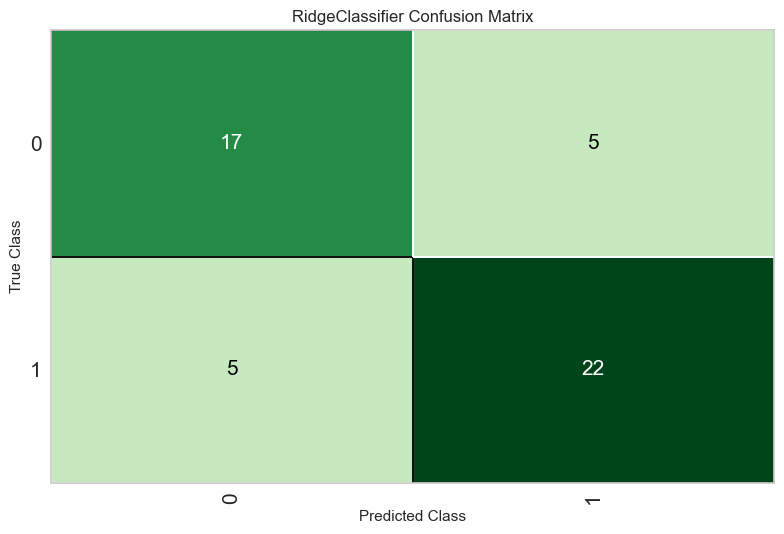

In [30]:
# Mostramos un plot
cl.plot_model(best_model, plot = 'confusion_matrix')

In [31]:
# Hacemos un resumen del mejor modelo
cl.pull()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ridge,Ridge Classifier,0.8187,0.8966,0.8736,0.8107,0.8390,0.6303,0.6379,0.011
lda,Linear Discriminant Analysis,0.8187,0.8966,0.8736,0.8107,0.8390,0.6303,0.6379,0.009
lr,Logistic Regression,0.8134,0.8943,0.8545,0.8150,0.8317,0.6202,0.6274,1.085
rf,Random Forest Classifier,0.8132,0.8788,0.8636,0.8090,0.8324,0.6202,0.6302,0.041
knn,K Neighbors Classifier,0.8079,0.8664,0.8627,0.8025,0.8261,0.6093,0.6254,0.012
nb,Naive Bayes,0.8076,0.8974,0.8355,0.8200,0.8226,0.6104,0.6210,0.008
et,Extra Trees Classifier,0.8024,0.8832,0.8245,0.8141,0.8148,0.6016,0.6111,0.042
qda,Quadratic Discriminant Analysis,0.7863,0.8801,0.7882,0.8103,0.7945,0.5721,0.5796,0.007
ada,Ada Boost Classifier,0.7663,0.8418,0.7955,0.7773,0.7821,0.5280,0.5368,0.014
gbc,Gradient Boosting Classifier,0.7558,0.8201,0.7873,0.7683,0.7752,0.5060,0.5121,0.020


In [32]:
# Hacemos una predicción con el mejor modelo
predictions = cl.predict_model(best_model, data=df_test_heart)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ridge Classifier,0.7705,0.7608,0.8788,0.7436,0.8056,0.5303,0.5413


In [35]:
predictions

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,prediction_label
179,57,1,0,150,276,0,0,112,1,0.6,1,1,1,0,0
197,67,1,0,125,254,1,1,163,0,0.2,1,2,3,0,0
285,46,1,0,140,311,0,1,120,1,1.8,1,2,3,0,0
194,60,1,2,140,185,0,0,155,0,3.0,1,0,2,0,1
188,50,1,2,140,233,0,1,163,0,0.6,1,1,3,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14,58,0,3,150,283,1,0,162,0,1.0,2,0,2,1,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1,1
224,54,1,0,110,239,0,1,126,1,2.8,1,1,3,0,0
202,58,1,0,150,270,0,0,111,1,0.8,2,0,3,0,0


## 2. NLP Clásico
Usaremos el dataset de tweets para hacer algunas transformaciones típicas que se utilizan para preprocesar texto e, incluso, hacer una predicción de análisis de sentimiento.

In [37]:
df_tweets

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14635,569587686496825344,positive,0.3487,NaN,0.0000,American,NaN,KristenReenders,NaN,0,@AmericanAir thank you we got on a different f...,NaN,2015-02-22 12:01:01 -0800,NaN,NaN
14636,569587371693355008,negative,1.0000,Customer Service Issue,1.0000,American,NaN,itsropes,NaN,0,@AmericanAir leaving over 20 minutes Late Flig...,NaN,2015-02-22 11:59:46 -0800,Texas,NaN
14637,569587242672398336,neutral,1.0000,NaN,NaN,American,NaN,sanyabun,NaN,0,@AmericanAir Please bring American Airlines to...,NaN,2015-02-22 11:59:15 -0800,"Nigeria,lagos",NaN
14638,569587188687634433,negative,1.0000,Customer Service Issue,0.6659,American,NaN,SraJackson,NaN,0,"@AmericanAir you have my money, you change my ...",NaN,2015-02-22 11:59:02 -0800,New Jersey,Eastern Time (US & Canada)


In [ ]:
# Comprueba la distribución de la variable objetivo
target_tweets = 'airline_sentiment'
df_tweets[target_tweets].value_counts()

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

In [41]:
# Mostramos algunos tweets positivos
df_tweets.loc[df_tweets[target_tweets] == 'positive', 'text'].sample(5, random_state=42)

6396     @SouthwestAir thanks for your excellent respon...
8484     @JetBlue thanks. I appreciate your prompt resp...
8417     @JetBlue yes, with about 20 minutes to spare. ...
11553    @USAirways YOU ARE THE BEST!!! FOLLOW ME PLEAS...
8106               @JetBlue beautiful ride. Thanks again:)
Name: text, dtype: object

In [42]:
# Mostramos algunos tweets negativos
df_tweets.loc[df_tweets[target_tweets] == 'negative', 'text'].sample(5, random_state=42)

1151     @united gate C 24 IAD. U released passengers t...
9111     @USAirways 1729 connecting in charlotte to hou...
3326     @united installed and working are not the same...
10891    @USAirways now I am on flight to FLL, and told...
11322    @USAirways ...Loosing a lot of business by usi...
Name: text, dtype: object

In [43]:
# Mostramos algunos tweets neutrales
df_tweets.loc[df_tweets[target_tweets] == 'neutral', 'text'].sample(5, random_state=42)

3569     @united we finally just arrive to Bogota, good...
13566    @AmericanAir got a callback at 1 am, took care...
7452                    @JetBlue is there wifi on he plain
6947                           @JetBlue @BucketObolts Same
5585                     @SouthwestAir how many are left?!
Name: text, dtype: object

### Preprocesamiento básico
Utilizaremos las siguientes librerías
- `re`: trabajo con expresiones regulares
- `nltk`: Procesamiento lingüístico básico: tokenización, stemming, lemmatización, análisis gramatical, corpus, etc.

Importamos las diferentes librerías:
```python
import nltk
import re
```

Algunas técnicas sencillas:
- **Tokenización**: Dividir un texto en partes más pequeñas llamadas tokens (palabras, frases o caracteres).
> Ejemplo: "Hoy es lunes." → ["Hoy", "es", "lunes", "."]

- **Stemming**: Reducir las palabras a su raíz o “stem”, eliminando sufijos. No siempre da palabras reales.
> Ejemplo: "correr", "corriendo", "corrió" → "corr"

- **Lematización**: Transformar las palabras a su forma base o “lema”, usando reglas lingüísticas (sí da palabras reales).
> Ejemplo: "mejores", "mejor", "mejorando" → "mejor"

- **Análisis gramatical (POS Tagging)**: Determinar la función gramatical de cada palabra (sustantivo, verbo, adjetivo, etc).
> Ejemplo: "corro" → "corro" (verbo)

In [ ]:
# Eliminamos las stopwords
nltk.download('stopwords')
spanish_stopwords = set(nltk.corpus.stopwords.words('spanish'))

[nltk_data] Downloading package stopwords to /Users/SERGIO-
[nltk_data]     BENITO/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [53]:
# Obtenemos las stopwords en inglés
english_stopwords = set(nltk.corpus.stopwords.words('english'))

In [55]:
# Mostramos las stopwords en español
spanish_stopwords

{'a',
 'al',
 'algo',
 'algunas',
 'algunos',
 'ante',
 'antes',
 'como',
 'con',
 'contra',
 'cual',
 'cuando',
 'de',
 'del',
 'desde',
 'donde',
 'durante',
 'e',
 'el',
 'ella',
 'ellas',
 'ellos',
 'en',
 'entre',
 'era',
 'erais',
 'eran',
 'eras',
 'eres',
 'es',
 'esa',
 'esas',
 'ese',
 'eso',
 'esos',
 'esta',
 'estaba',
 'estabais',
 'estaban',
 'estabas',
 'estad',
 'estada',
 'estadas',
 'estado',
 'estados',
 'estamos',
 'estando',
 'estar',
 'estaremos',
 'estará',
 'estarán',
 'estarás',
 'estaré',
 'estaréis',
 'estaría',
 'estaríais',
 'estaríamos',
 'estarían',
 'estarías',
 'estas',
 'este',
 'estemos',
 'esto',
 'estos',
 'estoy',
 'estuve',
 'estuviera',
 'estuvierais',
 'estuvieran',
 'estuvieras',
 'estuvieron',
 'estuviese',
 'estuvieseis',
 'estuviesen',
 'estuvieses',
 'estuvimos',
 'estuviste',
 'estuvisteis',
 'estuviéramos',
 'estuviésemos',
 'estuvo',
 'está',
 'estábamos',
 'estáis',
 'están',
 'estás',
 'esté',
 'estéis',
 'estén',
 'estés',
 'fue',
 'f

In [58]:
def clean_text(text: str, stopwords: set) -> str:
    """
    Limpia el texto eliminando puntuación, números y stopwords en español.
    Convierte el texto a minúsculas y devuelve una cadena de texto limpia.
    
    Args:
        text (str): Texto a limpiar.
        stopwords (set): Conjunto de stopwords a eliminar del texto.
    Returns:
        str: Texto limpio.
    """
    # Convertimos el texto a string y lo pasamos a minúsculas
    text = str(text).lower()
    
    # Eliminamos puntuación y números
    text = re.sub(r'[^\w\s]', '', text)  # Elimina puntuación
    text = re.sub(r'\d+', '', text)      # Elimina números

    # Eliminamos stopwords
    # Primero, dividimos el texto en tokens (palabras)
    tokens = text.split()
    tokens = [word for word in tokens if word not in stopwords]
    
    # Unimos los tokens de nuevo en una cadena de texto
    # y los devolvemos
    return ' '.join(tokens)

In [59]:
# Hacemos una función parcial para limpiar el texto en inglés
from functools import partial

clean_text_en = partial(clean_text, stopwords=english_stopwords)

In [60]:
# Aplicamos la limpieza
df_tweets['clean_text'] = df_tweets['text'].apply(clean_text_en)

In [49]:
# Ejemplo antes/después:
print(f"Antes: {df_tweets['text'].iloc[0]}")
print(f"Después: {df_tweets['clean_text'].iloc[0]}")

Antes: @VirginAmerica What @dhepburn said.
Después: virginamerica what dhepburn said


In [61]:
# Aplicamos un stemmer para reducir las palabras a su raíz
def stem_text(text: str):
    """    Aplica stemming al texto utilizando el Snowball Stemmer para español.
    Args:
        text (str): Texto a stemizar.
    Returns:
        str: Texto stemizado.
    """
    stemmer = nltk.stem.SnowballStemmer('english')  # Cambia 'english' por 'spanish' si quieres usar el stemmer en español
    # Utilizamos el stemmer para reducir las palabras a su raíz
    # Primero, dividimos el texto en tokens (palabras), aplicamos el stemmer a cada palabra
    # y los unimos de nuevo en una cadena de texto
    return ' '.join([stemmer.stem(word) for word in text.split()])

In [62]:
# Aplicamos el stemming al texto limpio
df_tweets['stemmed_text'] = df_tweets['clean_text'].apply(stem_text)
df_tweets[['clean_text', 'stemmed_text']].head()

,clean_text,stemmed_text
0,virginamerica dhepburn said,virginamerica dhepburn said
1,virginamerica plus youve added commercials exp...,virginamerica plus youv ad commerci experi tacki
2,virginamerica didnt today must mean need take ...,virginamerica didnt today must mean need take ...
3,virginamerica really aggressive blast obnoxiou...,virginamerica realli aggress blast obnoxi ente...
4,virginamerica really big bad thing,virginamerica realli big bad thing


### Entrenamiento del modelo
Ahora se puede trabajar como si fuera un caso similar a uno numérico, sólo hay que transformar a valores numéricos (con embeddings y vectorización) para luego poder inferir la clase

In [71]:
y_tweets

0         neutral
1        positive
2         neutral
3        negative
4        negative
           ...   
14635    positive
14636    negative
14637     neutral
14638    negative
14639     neutral
Name: airline_sentiment, Length: 14640, dtype: object

In [ ]:
# Ahora podemos trabajar con el texto limpio y stemizado para crear modelos de Machine Learning
X_tweets = df_tweets['clean_text']
y_tweets = df_tweets[target_tweets]

# División train/test
X_train, X_test, y_train, y_test = train_test_split(X_tweets, y_tweets, test_size=0.2, random_state=42)

# Bag-of-Words
bow_vectorizer = CountVectorizer(max_features=1000)
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

# TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=1000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [66]:
# Creamos el modelo
modelo_tweets_bow = DecisionTreeClassifier(random_state=42)
modelo_tweets_tfidf = DecisionTreeClassifier(random_state=42)

# Entrenamos el modelo usando las representaciones Bag-of-Words
modelo_tweets_bow.fit(X_train_bow, y_train)
modelo_tweets_tfidf.fit(X_train_tfidf, y_train)

DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='gini',
                       max_depth=None, max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, random_state=42, splitter='best')

In [67]:
# Ahora podemos hacer predicciones con los modelos entrenados
y_pred_bow = modelo_tweets_bow.predict(X_test_bow)
y_pred_tfidf = modelo_tweets_tfidf.predict(X_test_tfidf)

In [75]:
# Mostramos los classification reports
print("Classification Report - Bag-of-Words:")
print(classification_report(y_test, y_pred_bow))
print("Classification Report - TF-IDF:")
print(classification_report(y_test, y_pred_tfidf))

Classification Report - Bag-of-Words:
              precision    recall  f1-score   support

    negative       0.81      0.77      0.79      1889
     neutral       0.42      0.51      0.46       580
    positive       0.57      0.55      0.56       459

    accuracy                           0.68      2928
   macro avg       0.60      0.61      0.60      2928
weighted avg       0.70      0.68      0.69      2928

Classification Report - TF-IDF:
              precision    recall  f1-score   support

    negative       0.81      0.80      0.81      1889
     neutral       0.43      0.47      0.45       580
    positive       0.60      0.58      0.59       459

    accuracy                           0.70      2928
   macro avg       0.61      0.61      0.61      2928
weighted avg       0.70      0.70      0.70      2928



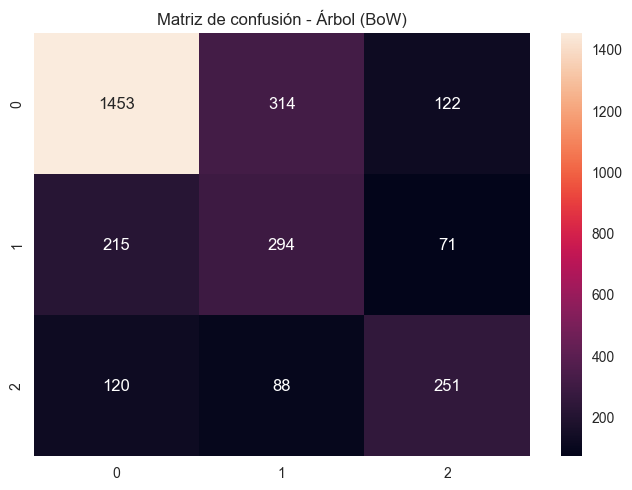

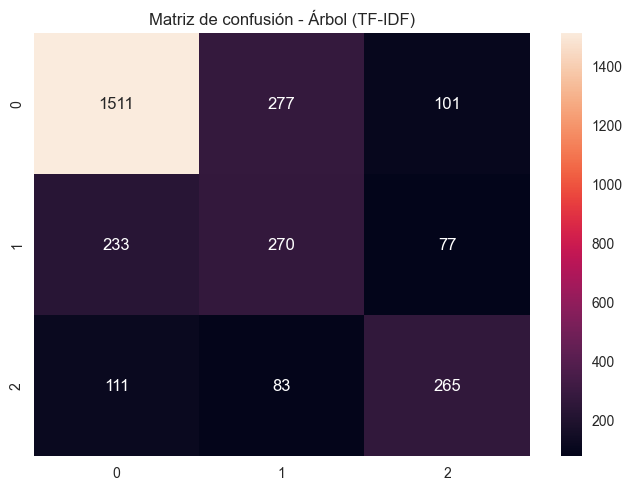

In [74]:
# Mostramos las matrices de confusión
confusion_bow = confusion_matrix(y_test, y_pred_bow)
confusion_tfidf = confusion_matrix(y_test, y_pred_tfidf)

# Mostramos las matrices de confusión
cm_tree_bow = confusion_matrix(y_test, y_pred_bow)
sns.heatmap(cm_tree_bow, annot=True, fmt='d')
plt.title('Matriz de confusión - Árbol (BoW)')
plt.show()

cm_tree_tfidf = confusion_matrix(y_test, y_pred_tfidf)
sns.heatmap(cm_tree_tfidf, annot=True, fmt='d')
plt.title('Matriz de confusión - Árbol (TF-IDF)')
plt.show()